In [ ]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# !pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118
%pip install torch==2.1.2 torchvision==0.16.2 torchaudio==2.1.2 --index-url https://download.pytorch.org/whl/cu118


Looking in indexes: https://download.pytorch.org/whl/cu118
ERROR: Could not find a version that satisfies the requirement torch==2.1.2 (from versions: 2.2.0+cu118, 2.2.1+cu118, 2.2.2+cu118, 2.3.0+cu118, 2.3.1+cu118, 2.4.0+cu118, 2.4.1+cu118, 2.5.0+cu118, 2.5.1+cu118, 2.6.0+cu118, 2.7.0+cu118, 2.7.1+cu118)
ERROR: No matching distribution found for torch==2.1.2


In [ ]:
!pip install supervision

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 217.4/217.4 kB 18.0 MB/s eta 0:00:00


In [ ]:
repository = "github.com/facebookresearch/sam2"

!git clone https://{username}:{token}@{repository}

%cd SAM2

!pip install -e .

!pip install -e ".[demo]"

%cd checkpoints
!bash download_ckpts.sh

%cd ..

Cloning into 'SAM2'...
remote: Enumerating objects: 316, done.
remote: Counting objects: 100% (316/316), done.
remote: Compressing objects: 100% (313/313), done.
remote: Total 316 (delta 25), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (316/316), 40.34 MiB | 14.85 MiB/s, done.
Resolving deltas: 100% (25/25), done.
/content/SAM2
Obtaining file:///content/SAM2
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 4.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.5/154.5 kB 19.0 MB/s eta 0:00:00
  Building editable for SAM-2 (pyproject.toml) ... done
  Created wheel for SAM-2: filename=sam_2-1.0-0.editable-cp312-cp312-linux_x86_64.whl size=12421 sha256=a47bcde478698298c8d09809f546db198a4aba9901bc4f

In [ ]:
def show_mask(mask, ax, random_color=False, borders = True):
    if random_color:
        color = np.concatenate([np.random.random(3), np.array([0.6])], axis=0)
    else:
        color = np.array([30/255, 144/255, 255/255, 0.6])
    h, w = mask.shape[-2:]
    mask = mask.astype(np.uint8)
    mask_image =  mask.reshape(h, w, 1) * color.reshape(1, 1, -1)
    if borders:
        import cv2
        contours, _ = cv2.findContours(mask,cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
        contours = [cv2.approxPolyDP(contour, epsilon=0.01, closed=True) for contour in contours]
        mask_image = cv2.drawContours(mask_image, contours, -1, (1, 1, 1, 0.5), thickness=2)
    ax.imshow(mask_image)

def show_points(coords, labels, ax, marker_size=375):
    pos_points = coords[labels==1]
    neg_points = coords[labels==0]
    ax.scatter(pos_points[:, 0], pos_points[:, 1], color='green', marker='*', s=marker_size, edgecolor='white', linewidth=1.25)
    ax.scatter(neg_points[:, 0], neg_points[:, 1], color='red', marker='*', s=marker_size, edgecolor='white', linewidth=1.25)

def show_box(box, ax):
    x0, y0 = box[0], box[1]
    w, h = box[2] - box[0], box[3] - box[1]
    ax.add_patch(plt.Rectangle((x0, y0), w, h, edgecolor='green', facecolor=(0, 0, 0, 0), lw=2))

def show_masks(image, masks, scores, point_coords=None, box_coords=None, input_labels=None, borders=True):
    for i, (mask, score) in enumerate(zip(masks, scores)):
        plt.figure(figsize=(10, 10))
        plt.imshow(image)
        show_mask(mask, plt.gca(), borders=borders)
        if point_coords is not None:
            assert input_labels is not None
            show_points(point_coords, input_labels, plt.gca())
        if box_coords is not None:
            show_box(box_coords, plt.gca())
        if len(scores) > 1:
            plt.title(f"Mask {i+1}, Score: {score:.3f}", fontsize=18)
        plt.axis('off')
        plt.show()

/content/SAM2/sam2/modeling/sam/transformer.py:23: UserWarning: Flash Attention is disabled as it requires a GPU with Ampere (8.0) CUDA capability.
  OLD_GPU, USE_FLASH_ATTN, MATH_KERNEL_ON = get_sdpa_settings()


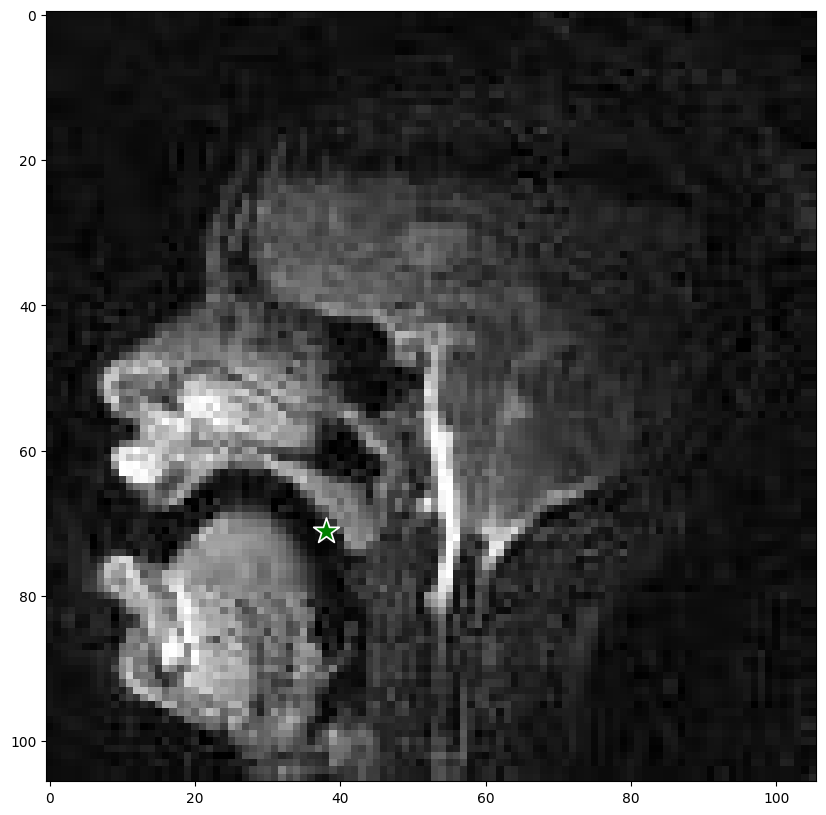

torch.Size([1, 256, 64, 64]) torch.Size([256, 64, 64])


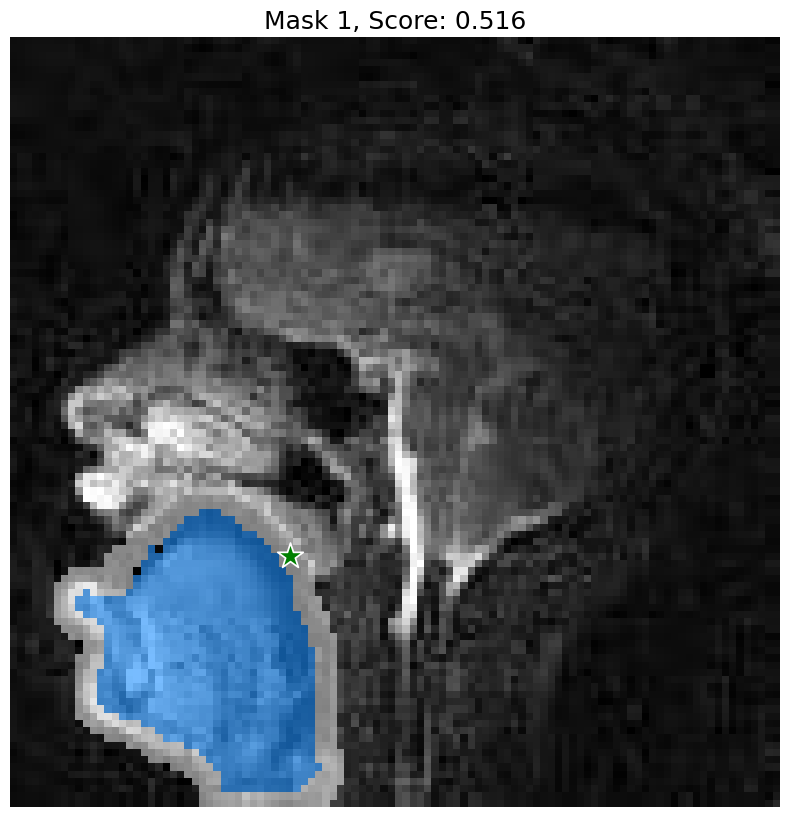

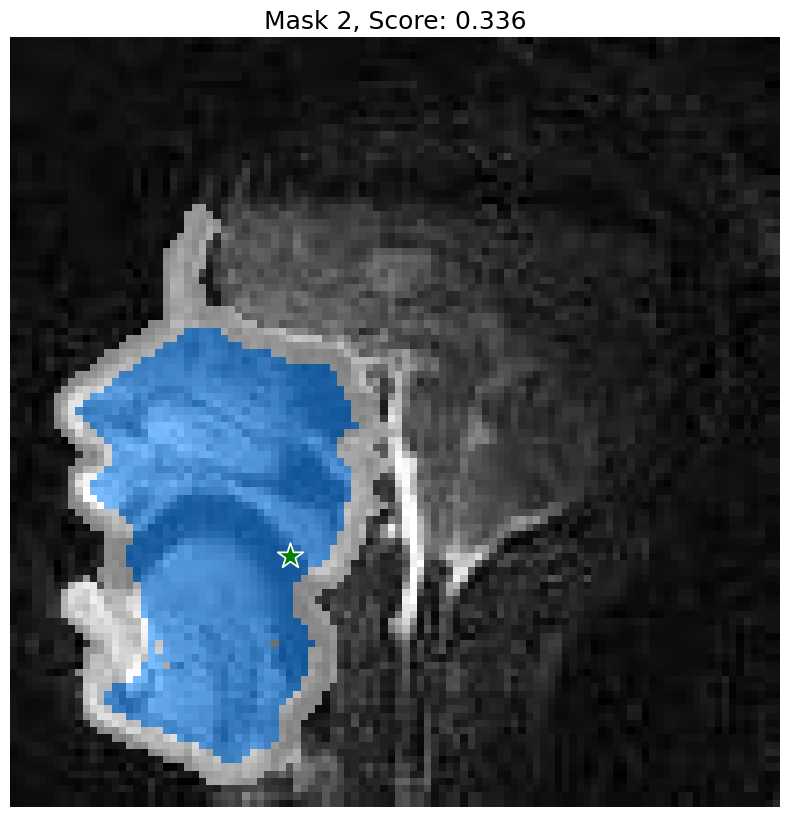

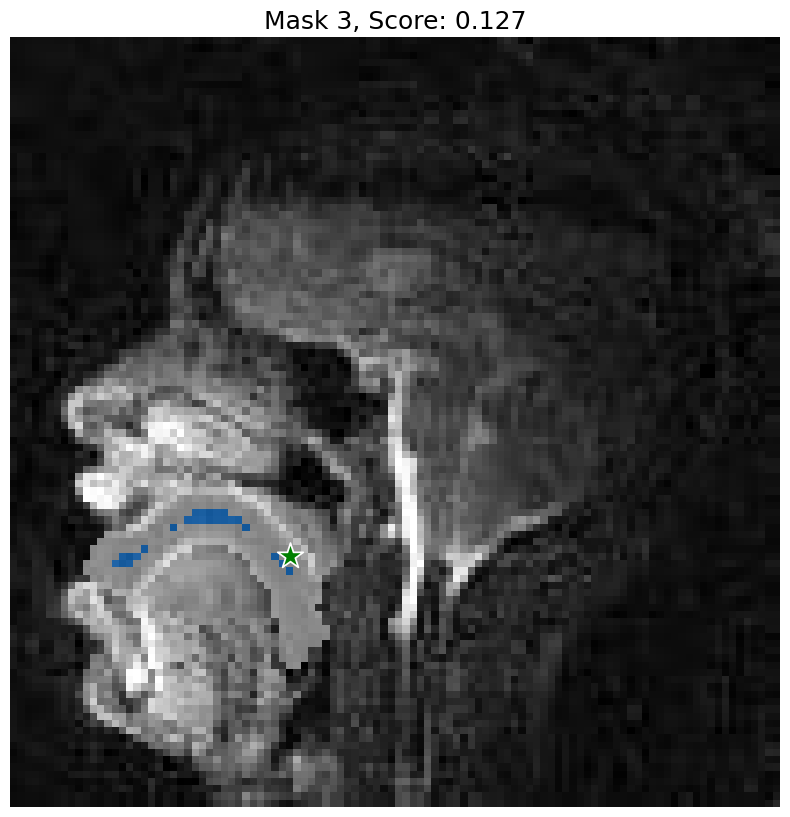

In [ ]:
import torch
from sam2.build_sam import build_sam2
from sam2.sam2_image_predictor import SAM2ImagePredictor
import cv2
import matplotlib.pyplot as plt
import numpy as np
from google.colab import drive
import supervision as sv
from PIL import Image

img = Image.open('/content/drive/My Drive/SAM2_demo_folder/img00.jpg')
image = np.array(img.convert("RGB"))

checkpoint = "./checkpoints/sam2_hiera_large.pt"
model_cfg = "sam2_hiera_l.yaml"

device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
sam2_model = build_sam2(model_cfg,checkpoint,device)
predictor = SAM2ImagePredictor(sam2_model)

predictor.set_image(image)
input_point = np.array([[38, 71]])
input_label = np.array([1])

plt.figure(figsize=(10, 10))
plt.imshow(image)
show_points(input_point, input_label, plt.gca())
plt.axis('on')
plt.show()

print(predictor._features["image_embed"].shape, predictor._features["image_embed"][-1].shape)

masks, scores, logits = predictor.predict(
    point_coords=input_point,
    point_labels=input_label,
    multimask_output=True,
)

sorted_ind = np.argsort(scores)[::-1]
masks = masks[sorted_ind]
scores = scores[sorted_ind]
logits = logits[sorted_ind]
show_masks(image, masks, scores, point_coords=input_point, input_labels=input_label, borders=True)


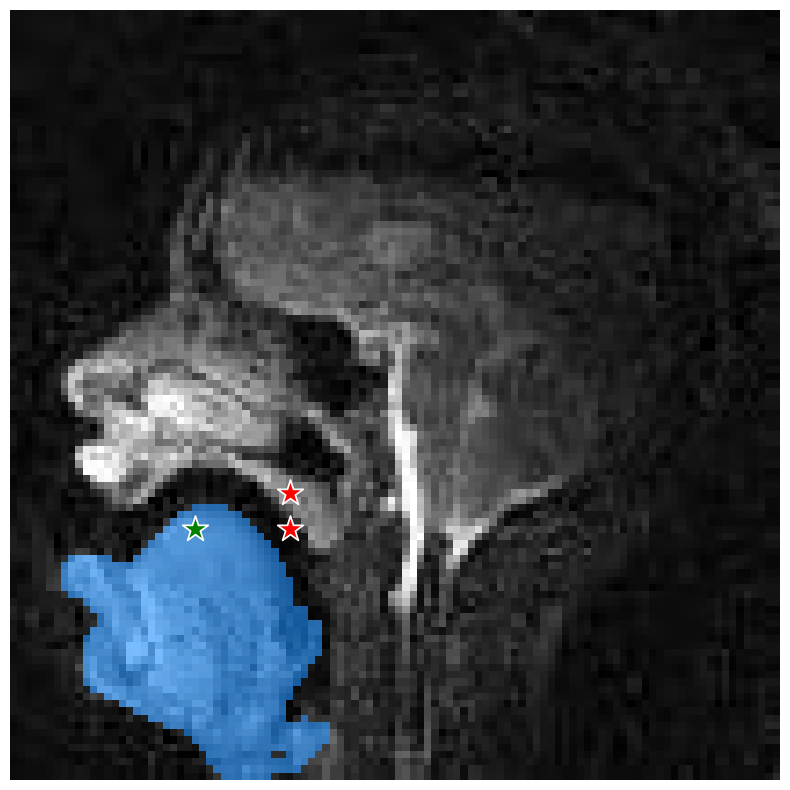

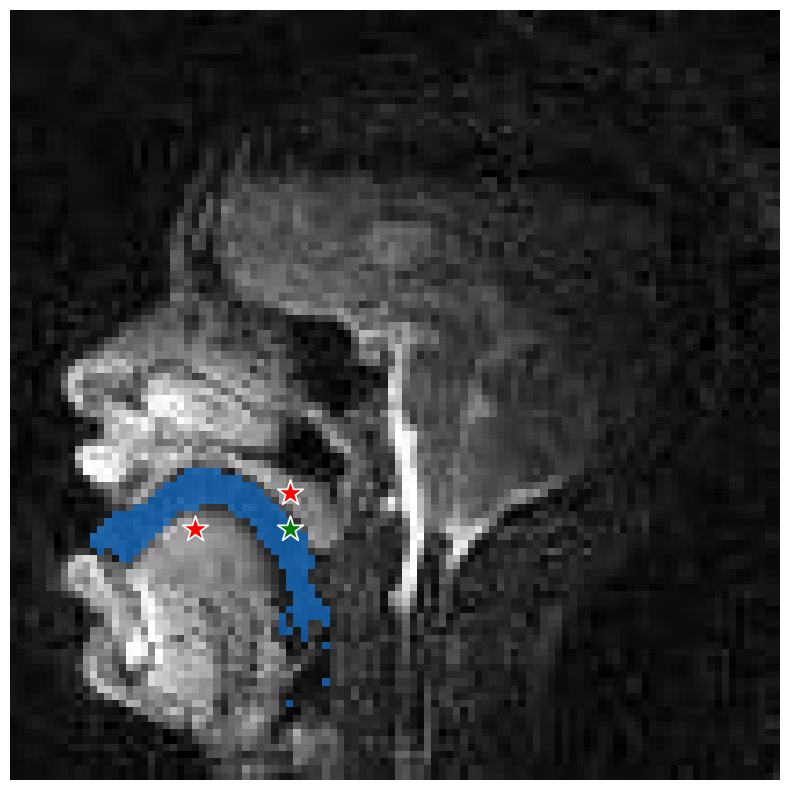

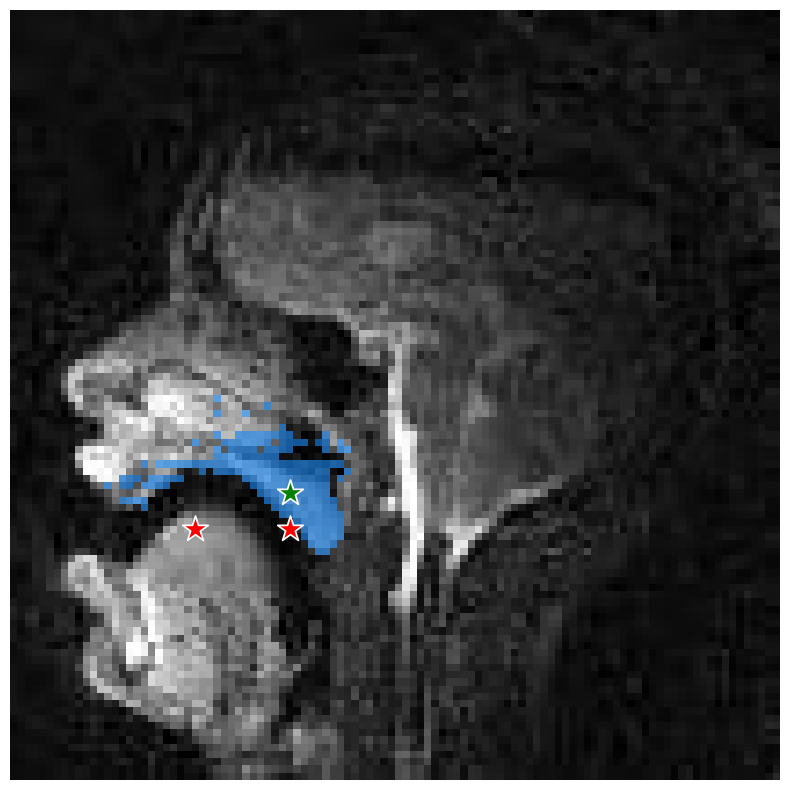

In [ ]:
input_point = np.array([[25,71],[38,71],[38,66]])
input_label = np.array([1,0,0])
mask_input = logits[np.argmax(scores), :, :]  # Choose the model's best mask

masks, scores, _ = predictor.predict(
    point_coords=input_point,
    point_labels=input_label,
    mask_input=mask_input[None, :, :],
    multimask_output=False,
)

masks.shape
show_masks(image, masks, scores, point_coords=input_point, input_labels=input_label, borders=False)

input_point = np.array([[25,71],[38,71],[38,66]])
input_label = np.array([0,1,0])
mask_input = logits[np.argmax(scores), :, :]  # Choose the model's best mask

masks, scores, _ = predictor.predict(
    point_coords=input_point,
    point_labels=input_label,
    mask_input=mask_input[None, :, :],
    multimask_output=False,
)

masks.shape
show_masks(image, masks, scores, point_coords=input_point, input_labels=input_label, borders=False)

input_point = np.array([[25,71],[38,71],[38,66]])
input_label = np.array([0,0,1])
mask_input = logits[np.argmax(scores), :, :]  # Choose the model's best mask

masks, scores, _ = predictor.predict(
    point_coords=input_point,
    point_labels=input_label,
    mask_input=mask_input[None, :, :],
    multimask_output=False,
)

masks.shape
show_masks(image, masks, scores, point_coords=input_point, input_labels=input_label, borders=False)




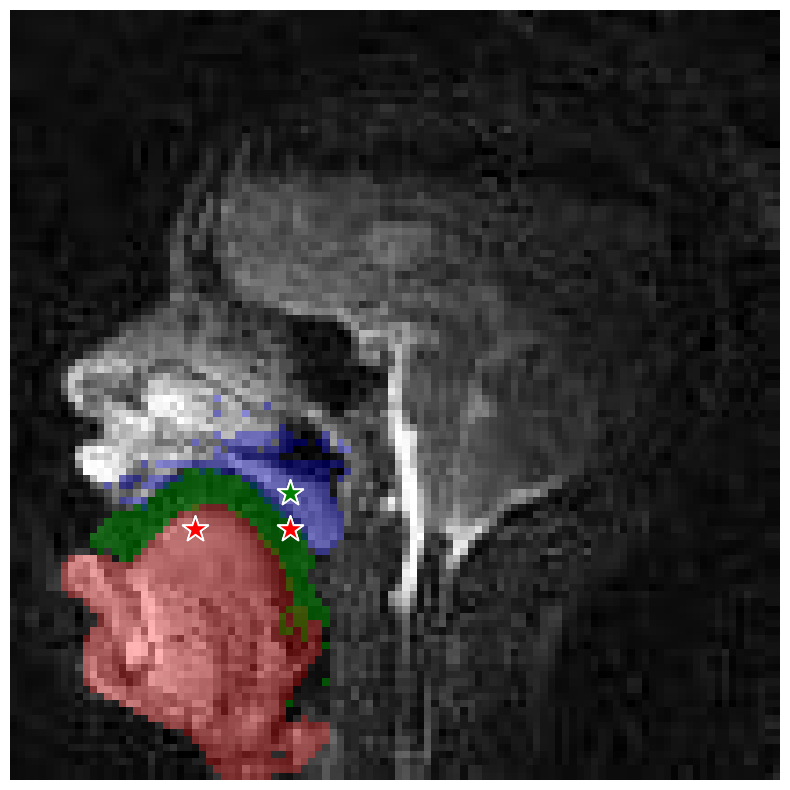

In [ ]:
img_path = '/content/drive/My Drive/SAM2_demo_folder/img00.jpg'
img = Image.open(img_path)
image = np.array(img.convert("RGB"))
checkpoint = "./checkpoints/sam2_hiera_large.pt"
model_cfg = "sam2_hiera_l.yaml"
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
sam2_model = build_sam2(model_cfg, checkpoint, device)
predictor = SAM2ImagePredictor(sam2_model)
predictor.set_image(image)

input_points_list = [
    np.array([[25,71],[38,71],[38,66]]),
    np.array([[25,71],[38,71],[38,66]]),
    np.array([[25,71],[38,71],[38,66]])
]

input_labels_list = [
    np.array([1,0,0]),
    np.array([0,1,0]),
    np.array([0,0,1])
]

def show_mask(mask, ax, color, borders=False):
    h, w = mask.shape[-2:]
    mask = mask.astype(np.uint8)
    mask_image = mask.reshape(h, w, 1) * np.array(color).reshape(1, 1, -1)
    if borders:
        import cv2
        contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
        contours = [cv2.approxPolyDP(contour, epsilon=0.01, closed=True) for contour in contours]
        mask_image = cv2.drawContours(mask_image, contours, -1, (1, 1, 1, 0.5), thickness=2)
    ax.imshow(mask_image, alpha=0.5)

colors = [
    [1, 0, 0, 0.6],  # Red
    [0, 1, 0, 0.6],  # Green
    [0, 0, 1, 0.6]   # Blue
]

def show_combined_masks(image, masks_list, colors, input_points_list, input_labels_list):
    plt.figure(figsize=(10, 10))
    plt.imshow(image)
    ax = plt.gca()
    for masks, color, points, labels in zip(masks_list, colors, input_points_list, input_labels_list):
        for mask in masks:
            show_mask(mask, ax, color, borders=False)
        show_points(points, labels, ax)
    plt.axis('off')
    plt.show()

masks_list = []
for input_points, input_labels in zip(input_points_list, input_labels_list):
    masks, scores, _ = predictor.predict(
        point_coords=input_points,
        point_labels=input_labels,
        mask_input=mask_input[None, :, :],
        multimask_output=False,
    )

    masks_list.append(masks)

show_combined_masks(image, masks_list, colors, input_points_list, input_labels_list)


In [ ]:
import os
os.environ["PYTORCH_ENABLE_MPS_FALLBACK"] = "1"
import numpy as np
import torch
import matplotlib.pyplot as plt
from PIL import Image
from sam2.build_sam import build_sam2_video_predictor

predictor = build_sam2_video_predictor(model_cfg, checkpoint, device=device)

def show_mask(mask, ax, obj_id=None, random_color=False):
    if random_color:
        color = np.concatenate([np.random.random(3), np.array([0.6])], axis=0)
    else:
        cmap = plt.get_cmap("tab10")
        cmap_idx = 0 if obj_id is None else obj_id
        color = np.array([*cmap(cmap_idx)[:3], 0.6])
    h, w = mask.shape[-2:]
    mask_image = mask.reshape(h, w, 1) * color.reshape(1, 1, -1)
    ax.imshow(mask_image)

def show_points(coords, labels, ax, marker_size=200):
    pos_points = coords[labels==1]
    neg_points = coords[labels==0]
    ax.scatter(pos_points[:, 0], pos_points[:, 1], color='green', marker='*', s=marker_size, edgecolor='white', linewidth=1.25)
    ax.scatter(neg_points[:, 0], neg_points[:, 1], color='red', marker='*', s=marker_size, edgecolor='white', linewidth=1.25)


# Model Segmentation

Mounted at /content/drive


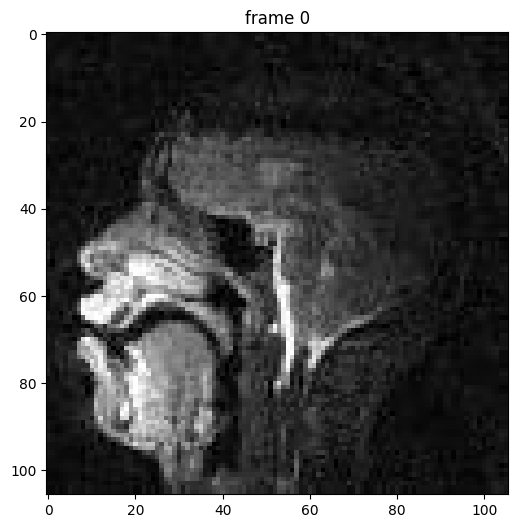

In [ ]:
import os

drive.mount('/content/drive', force_remount=True)
video_dir = '/content/drive/My Drive/SAM2_demo_folder/raw_img'

for filename in os.listdir(video_dir):
    if filename.startswith("frame") and filename.endswith((".jpg", ".jpeg", ".JPG", ".JPEG")): #can include .png if needed
        new_name = filename[5:]
        os.rename(os.path.join(video_dir, filename), os.path.join(video_dir, new_name))

video_dir = '/content/drive/My Drive/SAM2_demo_folder/raw_img'

frame_names = [
    p for p in os.listdir(video_dir)
    if os.path.splitext(p)[-1] in [".jpg", ".jpeg", ".JPG", ".JPEG"]
]

frame_names.sort(key=lambda p: int(os.path.splitext(p)[0]))

for frame_idx in range(len(frame_names)):
    frame_path = os.path.join(video_dir, frame_names[frame_idx])

    grayscale_image = Image.open(frame_path).convert('L')

frame_idx = 0
plt.figure(figsize=(9, 6))
plt.title(f"frame {frame_idx}")
plt.imshow(grayscale_image, cmap='gray')


In [ ]:
inference_state = predictor.init_state(video_path=video_dir)

frame loading (JPEG): 100%|██████████| 101/101 [00:02<00:00, 41.36it/s]


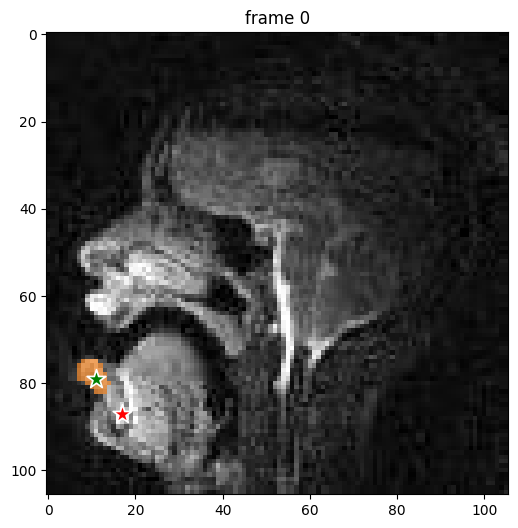

In [ ]:
ann_frame_idx = 0
ann_obj_id = 1  # give a unique id to each object we interact with (it can be any integer so long as it's different)

points = np.array([[17,87],[11,79]], dtype=np.float32)
labels = np.array([0,1], np.int32) # 1 = positive prompt, 0 = negative prompt
_, out_obj_ids, out_mask_logits = predictor.add_new_points_or_box(
    inference_state=inference_state,
    frame_idx=ann_frame_idx,
    obj_id=ann_obj_id,
    points=points,
    labels=labels,
)

img = Image.open(os.path.join(video_dir, frame_names[ann_frame_idx]))

plt.figure(figsize=(9, 6))
plt.title(f"frame {ann_frame_idx}")
plt.imshow(img, cmap='gray')
show_points(points, labels, plt.gca())
show_mask((out_mask_logits[0] > 0.0).cpu().numpy(), plt.gca(), obj_id=out_obj_ids[0])

In [ ]:
video_segments = {}  # video_segments contains the per-frame segmentation results
for out_frame_idx, out_obj_ids, out_mask_logits in predictor.propagate_in_video(inference_state):
    video_segments[out_frame_idx] = {
        out_obj_id: (out_mask_logits[i] > 0.0).cpu().numpy()
        for i, out_obj_id in enumerate(out_obj_ids)
    }

propagate in video: 100%|██████████| 101/101 [01:42<00:00,  1.02s/it]


In [ ]:
predictor.reset_state(inference_state)
prompts = {}

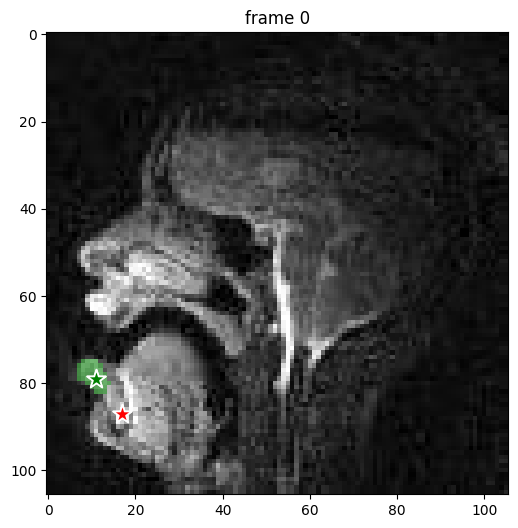

In [ ]:
# sample for detecting the lower lip
ann_frame_idx = 0
ann_obj_id = 2 # for other layers, copy this cell and assign ann_obj_id = 3, 4, etc.

points = np.array([[17,87],[11,79]], dtype=np.float32)
labels = np.array([0,1], np.int32)
prompts[ann_obj_id] = points, labels
_, out_obj_ids, out_mask_logits = predictor.add_new_points_or_box(
    inference_state=inference_state,
    frame_idx=ann_frame_idx,
    obj_id=ann_obj_id,
    points=points,
    labels=labels,
)

img = Image.open(os.path.join(video_dir, frame_names[ann_frame_idx]))

plt.figure(figsize=(9, 6))
plt.title(f"frame {ann_frame_idx}")
plt.imshow(img, cmap='gray')
show_points(points, labels, plt.gca())
for i, out_obj_id in enumerate(out_obj_ids):
    show_points(*prompts[out_obj_id], plt.gca())
    show_mask((out_mask_logits[i] > 0.0).cpu().numpy(), plt.gca(), obj_id=out_obj_id)


In [ ]:
video_segments = {}  # video_segments contains the per-frame segmentation results
for out_frame_idx, out_obj_ids, out_mask_logits in predictor.propagate_in_video(inference_state):
    video_segments[out_frame_idx] = {
        out_obj_id: (out_mask_logits[i] > 0.0).cpu().numpy()
        for i, out_obj_id in enumerate(out_obj_ids)
    }

propagate in video: 100%|██████████| 101/101 [01:40<00:00,  1.01it/s]


In [ ]:
# getting output part 1 - masks are overlaid onto the images

from PIL import Image, ImageOps
import matplotlib.pyplot as plt
import os
import io

output_dir = '/content/drive/My Drive/SAM2_demo_folder/output_raw_overlaid_LL' #LL = lower lip
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

vis_frame_stride = 1
image_counter = 1001 #sample provided is frames 1001-1100

for out_frame_idx in range(0, len(frame_names), vis_frame_stride):

    if out_frame_idx == 0: # skipping the initial frame we labeled as 00
        print(f"Skip frame {out_frame_idx}")
        continue

    img = Image.open(os.path.join(video_dir, frame_names[out_frame_idx])).convert('L')
    fig, ax = plt.subplots(figsize=(6, 4))
    ax.set_title(f"frame {out_frame_idx}")
    ax.imshow(img, cmap='gray')

    if out_frame_idx in video_segments:
        for out_obj_id, out_mask in video_segments[out_frame_idx].items():
            show_mask(out_mask, ax, obj_id=out_obj_id)

    buf = io.BytesIO()
    fig.savefig(buf, format='jpeg')
    buf.seek(0)

    pil_img = Image.open(buf)

    jpeg_path = os.path.join(output_dir, f"segmented_frame_{image_counter:04}.jpg")
    pil_img.save(jpeg_path, "JPEG", quality=95)

    plt.close(fig)

    print(f"Frame {image_counter:04} segmented.")

    image_counter += 1

Skip frame 0
Frame 1001 segmented.
Frame 1002 segmented.
Frame 1003 segmented.
Frame 1004 segmented.
Frame 1005 segmented.
Frame 1006 segmented.
Frame 1007 segmented.
Frame 1008 segmented.
Frame 1009 segmented.
Frame 1010 segmented.
Frame 1011 segmented.
Frame 1012 segmented.
Frame 1013 segmented.
Frame 1014 segmented.
Frame 1015 segmented.
Frame 1016 segmented.
Frame 1017 segmented.
Frame 1018 segmented.
Frame 1019 segmented.
Frame 1020 segmented.
Frame 1021 segmented.
Frame 1022 segmented.
Frame 1023 segmented.
Frame 1024 segmented.
Frame 1025 segmented.
Frame 1026 segmented.
Frame 1027 segmented.
Frame 1028 segmented.
Frame 1029 segmented.
Frame 1030 segmented.
Frame 1031 segmented.
Frame 1032 segmented.
Frame 1033 segmented.
Frame 1034 segmented.
Frame 1035 segmented.
Frame 1036 segmented.
Frame 1037 segmented.
Frame 1038 segmented.
Frame 1039 segmented.
Frame 1040 segmented.
Frame 1041 segmented.
Frame 1042 segmented.
Frame 1043 segmented.
Frame 1044 segmented.
Frame 1045 segmente

In [ ]:
# getting output part 2 - green lower lip mask only on a black square

output_dir = output_dir = '/content/drive/My Drive/SAM2_demo_folder/output_maskonly_LL'
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

vis_frame_stride = 1
image_counter = 1001 #sample provided is frames 1001-1100

for out_frame_idx in range(0, len(video_segments), vis_frame_stride):

    if out_frame_idx == 0:
        print(f"Skip frame {out_frame_idx}")
        continue

    # Create a black background for your desired, our dimensions are 106x106
    img_size = (106, 106)
    background_img = Image.new("RGB", img_size, color=(0, 0, 0))

    if out_frame_idx in video_segments:
        for out_obj_id, out_mask in video_segments[out_frame_idx].items():
            mask = np.array(out_mask)

            if mask.ndim != 2:
                mask = mask.squeeze()
            mask = (mask * 255).astype(np.uint8)
            mask_img = Image.fromarray(mask, mode="L").resize(img_size)
            mask_img = mask_img.convert("RGBA")
            mask_img = Image.merge("RGBA", (
                Image.new("L", img_size, 0),  # R
                Image.new("L", img_size, 128),  # G
                Image.new("L", img_size, 0),  # B
                mask_img.split()[0])
            )

            background_img.paste(mask_img, (0, 0), mask_img)

    jpeg_path = os.path.join(output_dir, f"mask_{image_counter:04}.jpg")
    background_img.convert("RGB").save(jpeg_path, "JPEG", quality=95)

    print(f"Frame {image_counter:04}'s mask saved.")

    image_counter += 1


Skip frame 0
Frame 1001's mask saved.
Frame 1002's mask saved.
Frame 1003's mask saved.
Frame 1004's mask saved.
Frame 1005's mask saved.
Frame 1006's mask saved.
Frame 1007's mask saved.
Frame 1008's mask saved.
Frame 1009's mask saved.
Frame 1010's mask saved.
Frame 1011's mask saved.
Frame 1012's mask saved.
Frame 1013's mask saved.
Frame 1014's mask saved.
Frame 1015's mask saved.
Frame 1016's mask saved.
Frame 1017's mask saved.
Frame 1018's mask saved.
Frame 1019's mask saved.
Frame 1020's mask saved.
Frame 1021's mask saved.
Frame 1022's mask saved.
Frame 1023's mask saved.
Frame 1024's mask saved.
Frame 1025's mask saved.
Frame 1026's mask saved.
Frame 1027's mask saved.
Frame 1028's mask saved.
Frame 1029's mask saved.
Frame 1030's mask saved.


Frame 1031's mask saved.
Frame 1032's mask saved.
Frame 1033's mask saved.
Frame 1034's mask saved.
Frame 1035's mask saved.
Frame 1036's mask saved.
Frame 1037's mask saved.
Frame 1038's mask saved.
Frame 1039's mask saved.
Frame 1040's mask saved.
Frame 1041's mask saved.
Frame 1042's mask saved.
Frame 1043's mask saved.
Frame 1044's mask saved.
Frame 1045's mask saved.
Frame 1046's mask saved.
Frame 1047's mask saved.
Frame 1048's mask saved.
Frame 1049's mask saved.
Frame 1050's mask saved.
Frame 1051's mask saved.
Frame 1052's mask saved.
Frame 1053's mask saved.
Frame 1054's mask saved.
Frame 1055's mask saved.
Frame 1056's mask saved.
Frame 1057's mask saved.
Frame 1058's mask saved.
Frame 1059's mask saved.
Frame 1060's mask saved.
Frame 1061's mask saved.
Frame 1062's mask saved.
Frame 1063's mask saved.
Frame 1064's mask saved.
Frame 1065's mask saved.
Frame 1066's mask saved.
Frame 1067's mask saved.
Frame 1068's mask saved.
Frame 1069's mask saved.
Frame 1070's mask saved.


# Edge detection

In [ ]:
# edge detection code

import cv2
import os
import glob
from google.colab import drive

drive.mount('/content/drive') # this can be done separately from the segmentation, but need to mount Drive

input_folder = '/content/drive/My Drive/SAM2_demo_folder/output_maskonly_LL'
output_folder = '/content/drive/My Drive/SAM2_demo_folder/output_maskonly_LL/output_LL_edge'

if not os.path.exists(output_folder):
    os.makedirs(output_folder)
    print(f"Created output folder: {output_folder}")
else:
    print(f"No need to create output folder: {output_folder}")

image_files = glob.glob(input_folder + '/*.jpg')

for img_path in image_files:
    img = cv2.imread(img_path, 0)

    if img is None:
        print(f"Error no image: {img_path}")
        continue

    edges = cv2.Canny(img, 100, 200) # can change these values if desired
    output_path = os.path.join(output_folder, os.path.basename(img_path))

    cv2.imwrite(output_path, edges)

print("Edge detection done and saved :)")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Created output folder: /content/drive/My Drive/SAM2_demo_folder/output_maskonly_LL/output_LL_edge
Edge detection done and saved :)
